In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

In [5]:
a = cursor.execute ('''
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
''')

In [6]:
cursor.execute("DELETE FROM sales")  # Clear previous data
sample_data = [
    ('Apple', 10, 0.5),
    ('Banana', 20, 0.2),
    ('Orange', 15, 0.3),
    ('Apple', 5, 0.5),
    ('Banana', 10, 0.2),
    ('Orange', 5, 0.3)
]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

In [8]:
query = '''
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
'''
df = pd.read_sql_query(query, conn)

In [9]:
print("Sales Summary:")
print(df)

Sales Summary:
  product  total_qty  revenue
0   Apple         15      7.5
1  Banana         30      6.0
2  Orange         20      6.0


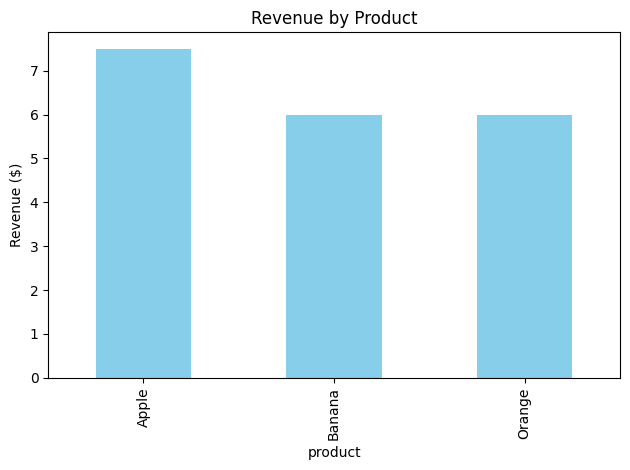

In [10]:
df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()